In [24]:
import pandas as pd

# ==============================
# Easy Organizer Theme Colors
# ==============================

EASY_PINK = "#F40AAE"
EASY_LIGHT_PINK = "#FF8DE3"
EASY_GREEN = "#8DBA2F"
EASY_DARK_GREEN = "#5F8F1F"
EASY_BLACK = "#050505"
EASY_WHITE = "#FFFFFF"
EASY_GRAY = "#F2F2F2"


# ==============================
# Table Styling Function
# ==============================

def easy_table_style(df, caption):
    return (
        df.style
        .set_caption(caption)
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "18px"),
                    ("font-weight", "bold"),
                    ("color", EASY_PINK),
                    ("padding", "10px")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", EASY_PINK),
                    ("color", EASY_WHITE),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border", f"1px solid {EASY_BLACK}"),
                    ("padding", "8px")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "center"),
                    ("border", f"1px solid {EASY_GRAY}"),
                    ("padding", "8px"),
                    ("font-size", "14px")
                ]
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "70%"),
                    ("margin", "15px auto"),
                    ("font-family", "Arial")
                ]
            }
        ])
        .set_properties(**{
            "background-color": EASY_WHITE,
            "color": EASY_BLACK
        })
    )

In [2]:
combined_table = pd.DataFrame({
    "Size": ["S", "M", "L", "XL", "XXL"],
    "Selling Price": [120, 170, 230, 300, 380],
    "Production Cost": [65, 95, 130, 180, 240],
    "Profit": [55, 75, 100, 120, 140],
    "PVC Usage (m²)": [0.45, 0.70, 0.95, 1.30, 1.75],
    "Fabric Usage (m²)": [0.30, 0.50, 0.75, 1.00, 1.40],
    "Production Time": ["10 min", "15 min", "20 min", "28 min", "35 min"],
    "Weekly Demand": [120, 100, 80, 55, 35],
    "Storage Units": [1, 2, 3, 5, 7]
})

easy_table_style(combined_table, "Easy Organizer Complete Data Table")

,Size,Selling Price,Production Cost,Profit,PVC Usage (m²),Fabric Usage (m²),Production Time,Weekly Demand,Storage Units
0,S,120,65,55,0.450000,0.300000,10 min,120,1
1,M,170,95,75,0.700000,0.500000,15 min,100,2
2,L,230,130,100,0.950000,0.750000,20 min,80,3
3,XL,300,180,120,1.300000,1.000000,28 min,55,5
4,XXL,380,240,140,1.750000,1.400000,35 min,35,7


In [25]:
product_info = pd.DataFrame({
    "Size": ["S", "M", "L", "XL", "XXL"],
    "Selling Price": [120, 170, 230, 300, 380],
    "Production Cost": [65, 95, 130, 180, 240],
    "Profit": [55, 75, 100, 120, 140]
})

easy_table_style(product_info, "Product Information")

,Size,Selling Price,Production Cost,Profit
0,S,120,65,55
1,M,170,95,75
2,L,230,130,100
3,XL,300,180,120
4,XXL,380,240,140


In [26]:
material_usage = pd.DataFrame({
    "Size": ["S", "M", "L", "XL", "XXL"],
    "PVC Usage (m²)": [0.45, 0.70, 0.95, 1.30, 1.75],
    "Fabric Usage (m²)": [0.30, 0.50, 0.75, 1.00, 1.40]
})

easy_table_style(material_usage, "Material Usage")

,Size,PVC Usage (m²),Fabric Usage (m²)
0,S,0.450000,0.300000
1,M,0.700000,0.500000
2,L,0.950000,0.750000
3,XL,1.300000,1.000000
4,XXL,1.750000,1.400000


In [28]:
production_time = pd.DataFrame({
    "Size": ["S", "M", "L", "XL", "XXL"],
    "Production Time": ["10 min", "15 min", "20 min", "28 min", "35 min"]
})

easy_table_style(production_time, "Production Time")

,Size,Production Time
0,S,10 min
1,M,15 min
2,L,20 min
3,XL,28 min
4,XXL,35 min


#  Constraints + Resources

In [35]:
factory_limits = pd.DataFrame({
    "Resource": [
        "PVC Available",
        "Fabric Available",
        "Labor Time",
        "Storage Capacity"
    ],
    "Weekly Limit": [
        "500 m²",
        "400 m²",
        "15000 min",
        "1000 units"
    ]
})

easy_table_style(factory_limits, "Factory Resource Limits")

,Resource,Weekly Limit
0,PVC Available,500 m²
1,Fabric Available,400 m²
2,Labor Time,15000 min
3,Storage Capacity,1000 units


In [36]:
constraints_table = pd.DataFrame({
    "Constraint": [
        "PVC Constraint",
        "Fabric Constraint",
        "Labor Constraint",
        "Storage Constraint",
        "Demand Constraint"
    ],
    "Description": [
        "Total PVC usage cannot exceed available PVC",
        "Total fabric usage cannot exceed available fabric",
        "Total production time cannot exceed labor capacity",
        "Total storage usage cannot exceed storage capacity",
        "Production should satisfy customer demand"
    ]
})

easy_table_style(constraints_table, "Optimization Constraints")

,Constraint,Description
0,PVC Constraint,Total PVC usage cannot exceed available PVC
1,Fabric Constraint,Total fabric usage cannot exceed available fabric
2,Labor Constraint,Total production time cannot exceed labor capacity
3,Storage Constraint,Total storage usage cannot exceed storage capacity
4,Demand Constraint,Production should satisfy customer demand


In [1]:
import cvxpy as cp
import numpy as np

In [38]:
EASY_PINK = "#F40AAE"
EASY_LIGHT_PINK = "#FF8DE3"
EASY_GREEN = "#8DBA2F"
EASY_DARK_GREEN = "#5F8F1F"
EASY_BLACK = "#050505"
EASY_WHITE = "#FFFFFF"
EASY_GRAY = "#D9D9D9"

easy_palette = [
    EASY_PINK,
    EASY_LIGHT_PINK,
    EASY_GREEN,
    EASY_DARK_GREEN,
    EASY_GRAY
]

In [2]:
sizes = ["S", "M", "L", "XL", "XXL"]

demand = np.array([120, 100, 80, 55, 35])
profit = np.array([55, 75, 100, 120, 140])

pvc_usage = np.array([0.45, 0.70, 0.95, 1.30, 1.75])
fabric_usage = np.array([0.30, 0.50, 0.75, 1.00, 1.40])

production_time = np.array([10, 15, 20, 28, 35])
storage_space = np.array([1, 2, 3, 5, 7])

MAX_PVC = 500
MAX_FABRIC = 400
MAX_TIME = 15000
MAX_STORAGE = 1000

In [3]:
x = cp.Variable(len(sizes), integer=True)

shortage = cp.Variable(len(sizes))
waste_pvc = cp.Variable()
waste_fabric = cp.Variable()

In [4]:
total_profit = profit @ x

used_pvc = pvc_usage @ x
used_fabric = fabric_usage @ x

total_time = production_time @ x
total_storage = storage_space @ x

total_waste = waste_pvc + waste_fabric
total_shortage = cp.sum(shortage)

In [5]:
constraints = [
    x >= 0,

    shortage >= 0,
    shortage >= demand - x,

    used_pvc <= MAX_PVC,
    used_fabric <= MAX_FABRIC,
    total_time <= MAX_TIME,
    total_storage <= MAX_STORAGE,

    waste_pvc == MAX_PVC - used_pvc,
    waste_fabric == MAX_FABRIC - used_fabric,

    waste_pvc >= 0,
    waste_fabric >= 0,

    x <= demand
]

In [6]:
objective = cp.Maximize(total_profit)

In [7]:
problem = cp.Problem(objective, constraints)
problem.solve()

print("Status:", problem.status)
print("Optimal Value:", problem.value)

Status: optimal
Optimal Value: 31960.0


In [8]:
print("Production Plan:")
for i in range(len(sizes)):
    print(f"{sizes[i]}: {round(x.value[i])}")

print("\nResource Usage:")
print("Total Profit:", total_profit.value)
print("PVC Used:", used_pvc.value)
print("Fabric Used:", used_fabric.value)
print("Production Time:", total_time.value)
print("Storage Used:", total_storage.value)

print("\nWaste:")
print("PVC Waste:", waste_pvc.value)
print("Fabric Waste:", waste_fabric.value)

print("\nShortage:")
for i in range(len(sizes)):
    print(f"{sizes[i]} shortage: {round(shortage.value[i])}")

Production Plan:
S: 120
M: 100
L: 79
XL: 55
XXL: 24

Resource Usage:
Total Profit: 31960.0
PVC Used: 312.55
Fabric Used: 233.85
Production Time: 6660.0
Storage Used: 1000.0

Waste:
PVC Waste: 187.45000000000002
Fabric Waste: 166.15

Shortage:
S shortage: 0
M shortage: 0
L shortage: 1
XL shortage: 0
XXL shortage: 11


## Sensitivity Analysis for PVC

In [10]:
pvc_scenarios = [350, 400, 450, 500, 550, 600]

results = []

for pvc_limit in pvc_scenarios:

    # Decision variable
    x = cp.Variable(len(sizes), integer=True)

    # Calculations
    total_profit = profit @ x
    used_pvc = pvc_usage @ x
    used_fabric = fabric_usage @ x
    total_time = production_time @ x
    total_storage = storage_space @ x

    waste_pvc = pvc_limit - used_pvc
    waste_fabric = MAX_FABRIC - used_fabric

    shortage = demand - x
    total_shortage = cp.sum(shortage)

    # Constraints
    constraints = [
        x >= 0,
        x <= demand,

        used_pvc <= pvc_limit,
        used_fabric <= MAX_FABRIC,
        total_time <= MAX_TIME,
        total_storage <= MAX_STORAGE
    ]

    # Objective function
    # Main goal: maximize total profit
    objective = cp.Maximize(total_profit)

    # Solve problem
    problem = cp.Problem(objective, constraints)
    problem.solve()

    # Save results
    results.append([
        pvc_limit,
        problem.value,
        total_profit.value,
        used_pvc.value,
        used_fabric.value,
        total_time.value,
        total_storage.value,
        waste_pvc.value,
        waste_fabric.value,
        total_shortage.value,
        x.value
    ])

In [11]:
for r in results:
    print("PVC Limit:", r[0])
    print("Objective Value:", round(r[1], 2))
    print("Total Profit:", round(r[2], 2))
    print("PVC Used:", round(r[3], 2))
    print("Total Shortage:", round(r[4], 2))
    print("Production Plan:", np.round(r[5]))
    print("-" * 40)

PVC Limit: 350
Objective Value: 31960.0
Total Profit: 31960.0
PVC Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
PVC Limit: 400
Objective Value: 31960.0
Total Profit: 31960.0
PVC Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
PVC Limit: 450
Objective Value: 31960.0
Total Profit: 31960.0
PVC Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
PVC Limit: 500
Objective Value: 31960.0
Total Profit: 31960.0
PVC Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
PVC Limit: 550
Objective Value: 31960.0
Total Profit: 31960.0
PVC Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
PVC Limit: 600
Objective Value: 31960.0
Total Profit: 31960.0
PVC Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
---------------------------------------

In [12]:
## yb'a kda PVC msh bottlneck

In [14]:
time_scenarios = [9000, 11000, 13000, 15000, 17000, 19000]

results_time = []

for time_limit in time_scenarios:

    # Decision variable
    x = cp.Variable(len(sizes), integer=True)

    # Calculations
    total_profit = profit @ x
    used_pvc = pvc_usage @ x
    used_fabric = fabric_usage @ x
    total_time = production_time @ x
    total_storage = storage_space @ x

    waste_pvc = MAX_PVC - used_pvc
    waste_fabric = MAX_FABRIC - used_fabric

    shortage = demand - x
    total_shortage = cp.sum(shortage)

    # Constraints
    constraints = [
        x >= 0,
        x <= demand,

        used_pvc <= MAX_PVC,
        used_fabric <= MAX_FABRIC,
        total_time <= time_limit,
        total_storage <= MAX_STORAGE
    ]

    # Objective function
    # Main goal: maximize total profit
    objective = cp.Maximize(total_profit)

    # Solve problem
    problem = cp.Problem(objective, constraints)
    problem.solve()

    # Save results
    results_time.append([
        time_limit,
        problem.value,
        total_profit.value,
        used_pvc.value,
        used_fabric.value,
        total_time.value,
        total_storage.value,
        waste_pvc.value,
        waste_fabric.value,
        total_shortage.value,
        x.value
    ])

In [15]:
for r in results_time:
    print("Time Limit:", r[0])
    print("Objective Value:", round(r[1], 2))
    print("Total Profit:", round(r[2], 2))
    print("Time Used:", round(r[3], 2))
    print("Total Shortage:", round(r[4], 2))
    print("Production Plan:", np.round(r[5]))
    print("-" * 40)

Time Limit: 9000
Objective Value: 31960.0
Total Profit: 31960.0
Time Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
Time Limit: 11000
Objective Value: 31960.0
Total Profit: 31960.0
Time Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
Time Limit: 13000
Objective Value: 31960.0
Total Profit: 31960.0
Time Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
Time Limit: 15000
Objective Value: 31960.0
Total Profit: 31960.0
Time Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
Time Limit: 17000
Objective Value: 31960.0
Total Profit: 31960.0
Time Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------------------------------
Time Limit: 19000
Objective Value: 31960.0
Total Profit: 31960.0
Time Used: 312.55
Total Shortage: 233.85
Production Plan: 6660.0
----------------

In [16]:
## ,so not time bottlneck too i think the bottleneck will comes from the storage  

In [18]:
storage_scenarios = [700, 800, 900, 1000, 1100, 1200]

results_storage = []

for storage_limit in storage_scenarios:

    # Decision variable
    x = cp.Variable(len(sizes), integer=True)

    # Calculations
    total_profit = profit @ x
    used_pvc = pvc_usage @ x
    used_fabric = fabric_usage @ x
    total_time = production_time @ x
    total_storage = storage_space @ x

    waste_pvc = MAX_PVC - used_pvc
    waste_fabric = MAX_FABRIC - used_fabric

    shortage = demand - x
    total_shortage = cp.sum(shortage)

    # Constraints
    constraints = [
        x >= 0,
        x <= demand,

        used_pvc <= MAX_PVC,
        used_fabric <= MAX_FABRIC,
        total_time <= MAX_TIME,
        total_storage <= storage_limit
    ]

    # Objective function
    # Main goal: maximize total profit
    objective = cp.Maximize(total_profit)

    # Solve problem
    problem = cp.Problem(objective, constraints)
    problem.solve()

    # Save results
    results_storage.append([
        storage_limit,
        problem.value,
        total_profit.value,
        used_pvc.value,
        used_fabric.value,
        total_time.value,
        total_storage.value,
        waste_pvc.value,
        waste_fabric.value,
        total_shortage.value,
        x.value
    ])

# Print results
for r in results_storage:
    print("Storage Limit:", r[0])
    print("Objective Value:", round(r[1], 2))
    print("Total Profit:", round(r[2], 2))
    print("PVC Used:", round(r[3], 2))
    print("Fabric Used:", round(r[4], 2))
    print("Production Time:", round(r[5], 2))
    print("Storage Used:", round(r[6], 2))
    print("PVC Waste:", round(r[7], 2))
    print("Fabric Waste:", round(r[8], 2))
    print("Total Shortage:", round(r[9], 2))
    print("Production Plan:", np.round(r[10]))
    print("-" * 40)

Storage Limit: 700
Objective Value: 25460.0
Total Profit: 25460.0
PVC Used: 236.4
Fabric Used: 174.0
Production Time: 5084.0
Storage Used: 700.0
PVC Waste: 263.6
Fabric Waste: 226.0
Total Shortage: 62.0
Production Plan: [120. 100.  80.  28.  -0.]
----------------------------------------
Storage Limit: 800
Objective Value: 27860.0
Total Profit: 27860.0
PVC Used: 262.4
Fabric Used: 194.0
Production Time: 5644.0
Storage Used: 800.0
PVC Waste: 237.6
Fabric Waste: 206.0
Total Shortage: 42.0
Production Plan: [120. 100.  80.  48.  -0.]
----------------------------------------
Storage Limit: 900
Objective Value: 29980.0
Total Profit: 29980.0
PVC Used: 287.7
Fabric Used: 214.0
Production Time: 6162.0
Storage Used: 900.0
PVC Waste: 212.3
Fabric Waste: 186.0
Total Shortage: 26.0
Production Plan: [120. 100.  80.  54.  10.]
----------------------------------------
Storage Limit: 1000
Objective Value: 31960.0
Total Profit: 31960.0
PVC Used: 312.55
Fabric Used: 233.85
Production Time: 6660.0
Storage 

In [ ]:
## the bottleneck is hereee

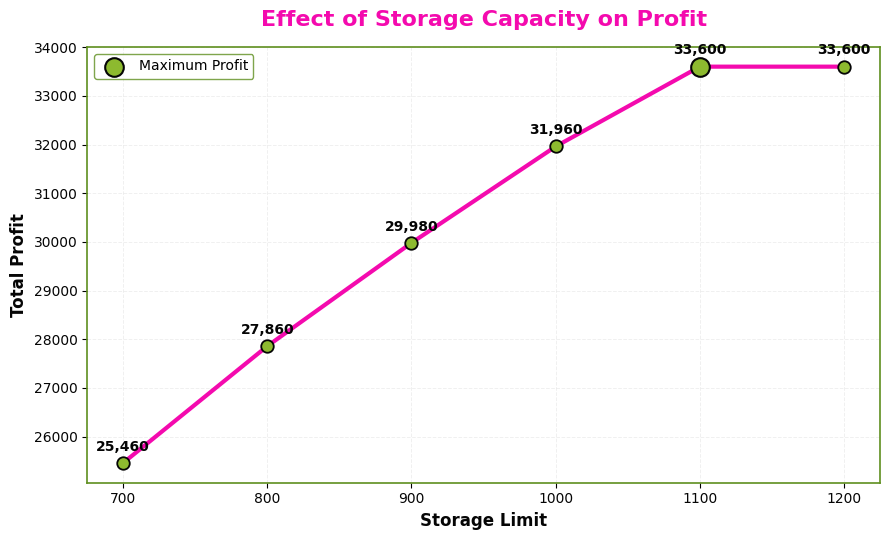

In [46]:

# Data
storage_limits = [700, 800, 900, 1000, 1100, 1200]
profits = [25460, 27860, 29980, 31960, 33600, 33600]

# Easy Organizer Theme Colors
EASY_PINK = "#F40AAE"
EASY_LIGHT_PINK = "#FF8DE3"
EASY_GREEN = "#8DBA2F"
EASY_DARK_GREEN = "#5F8F1F"
EASY_BLACK = "#050505"
EASY_WHITE = "#FFFFFF"
EASY_GRAY = "#D9D9D9"

# Create figure
plt.figure(figsize=(9, 5.5), facecolor=EASY_WHITE)

# Plot line
plt.plot(
    storage_limits,
    profits,
    color=EASY_PINK,
    linewidth=3,
    marker='o',
    markersize=9,
    markerfacecolor=EASY_GREEN,
    markeredgecolor=EASY_BLACK,
    markeredgewidth=1.3
)

# Add value labels
for x, y in zip(storage_limits, profits):
    plt.text(
        x,
        y + 250,
        f"{y:,}",
        ha='center',
        fontsize=10,
        color=EASY_BLACK,
        fontweight='bold'
    )

# Titles and labels
plt.title(
    "Effect of Storage Capacity on Profit",
    fontsize=16,
    fontweight='bold',
    color=EASY_PINK,
    pad=15
)

plt.xlabel(
    "Storage Limit",
    fontsize=12,
    fontweight='bold',
    color=EASY_BLACK
)

plt.ylabel(
    "Total Profit",
    fontsize=12,
    fontweight='bold',
    color=EASY_BLACK
)

# Grid and background
plt.grid(
    True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.4,
    color=EASY_GRAY
)

plt.gca().set_facecolor(EASY_WHITE)

# Axis styling
plt.xticks(storage_limits, fontsize=10, color=EASY_BLACK)
plt.yticks(fontsize=10, color=EASY_BLACK)

for spine in plt.gca().spines.values():
    spine.set_color(EASY_DARK_GREEN)
    spine.set_linewidth(1.2)

# Highlight maximum profit point
max_profit = max(profits)
max_index = profits.index(max_profit)

plt.scatter(
    storage_limits[max_index],
    max_profit,
    s=180,
    color=EASY_GREEN,
    edgecolor=EASY_BLACK,
    linewidth=1.5,
    zorder=5,
    label="Maximum Profit"
)

plt.legend(
    facecolor=EASY_WHITE,
    edgecolor=EASY_DARK_GREEN,
    fontsize=10
)

plt.tight_layout()
plt.show()

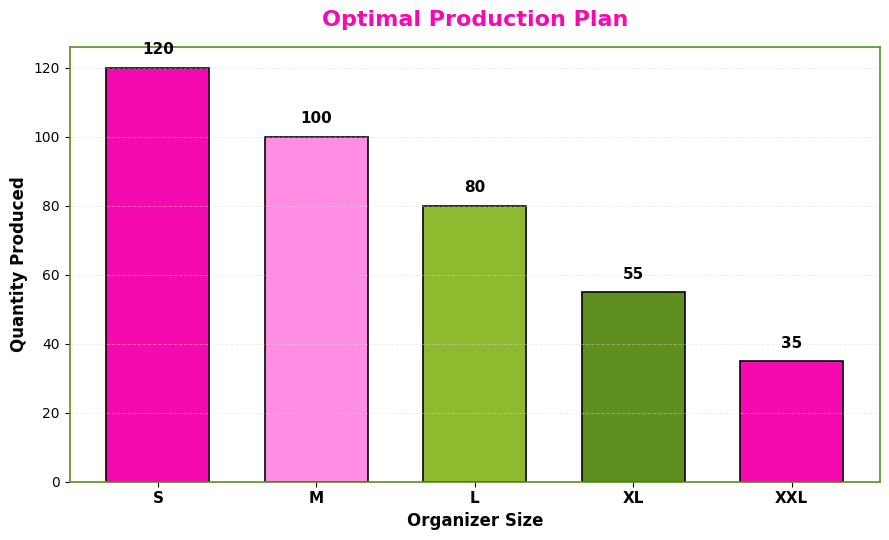

In [45]:
# Data
sizes = ["S", "M", "L", "XL", "XXL"]
production = [120, 100, 80, 55, 35]

# Easy Organizer Theme Colors
EASY_PINK = "#F40AAE"
EASY_LIGHT_PINK = "#FF8DE3"
EASY_GREEN = "#8DBA2F"
EASY_DARK_GREEN = "#5F8F1F"
EASY_BLACK = "#050505"
EASY_WHITE = "#FFFFFF"
EASY_GRAY = "#D9D9D9"

# Bar colors based on the logo
bar_colors = [
    EASY_PINK,
    EASY_LIGHT_PINK,
    EASY_GREEN,
    EASY_DARK_GREEN,
    EASY_PINK
]

# Create figure
plt.figure(figsize=(9, 5.5), facecolor=EASY_WHITE)

# Create bar chart
bars = plt.bar(
    sizes,
    production,
    color=bar_colors,
    edgecolor=EASY_BLACK,
    linewidth=1.2,
    width=0.65
)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3,
        str(height),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=EASY_BLACK
    )

# Titles and labels
plt.title(
    "Optimal Production Plan",
    fontsize=16,
    fontweight="bold",
    color=EASY_PINK,
    pad=15
)

plt.xlabel(
    "Organizer Size",
    fontsize=12,
    fontweight="bold",
    color=EASY_BLACK
)

plt.ylabel(
    "Quantity Produced",
    fontsize=12,
    fontweight="bold",
    color=EASY_BLACK
)

# Background and grid
plt.gca().set_facecolor(EASY_WHITE)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.4,
    color=EASY_GRAY
)

# Axis styling
plt.xticks(fontsize=11, fontweight="bold", color=EASY_BLACK)
plt.yticks(fontsize=10, color=EASY_BLACK)

for spine in plt.gca().spines.values():
    spine.set_color(EASY_DARK_GREEN)
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

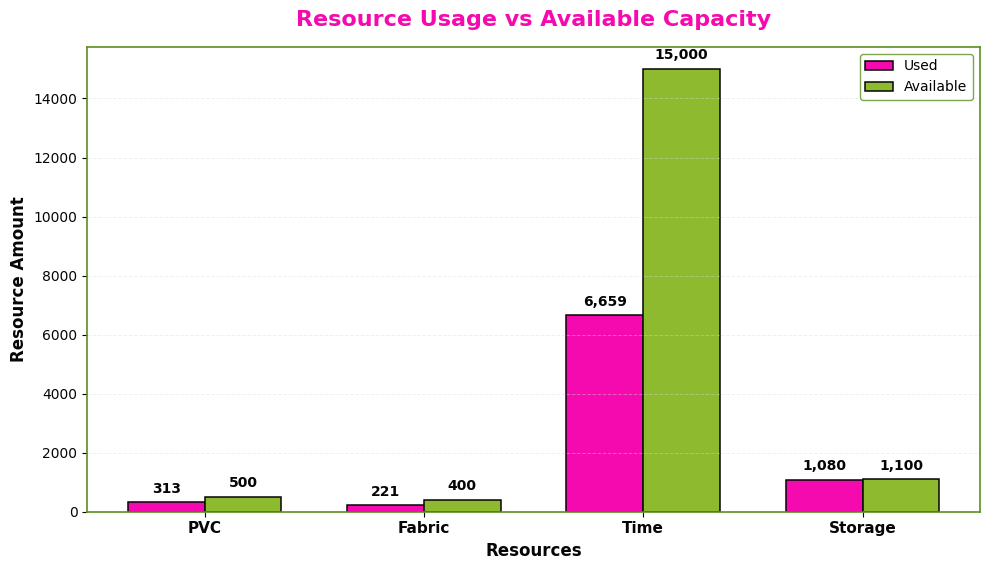

In [44]:
# Data
resources = ["PVC", "Fabric", "Time", "Storage"]

used = [312.65, 221, 6659, 1080]
available = [500, 400, 15000, 1100]

# Easy Organizer Theme Colors
EASY_PINK = "#F40AAE"
EASY_LIGHT_PINK = "#FF8DE3"
EASY_GREEN = "#8DBA2F"
EASY_DARK_GREEN = "#5F8F1F"
EASY_BLACK = "#050505"
EASY_WHITE = "#FFFFFF"
EASY_GRAY = "#D9D9D9"

# X positions
x = np.arange(len(resources))
width = 0.35

# Create figure
plt.figure(figsize=(10, 5.8), facecolor=EASY_WHITE)

# Create bars
bars_used = plt.bar(
    x - width / 2,
    used,
    width,
    label="Used",
    color=EASY_PINK,
    edgecolor=EASY_BLACK,
    linewidth=1.1
)

bars_available = plt.bar(
    x + width / 2,
    available,
    width,
    label="Available",
    color=EASY_GREEN,
    edgecolor=EASY_BLACK,
    linewidth=1.1
)

# Add value labels
for bars in [bars_used, bars_available]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(available) * 0.015,
            f"{height:,.0f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color=EASY_BLACK
        )

# Titles and labels
plt.title(
    "Resource Usage vs Available Capacity",
    fontsize=16,
    fontweight="bold",
    color=EASY_PINK,
    pad=15
)

plt.xlabel(
    "Resources",
    fontsize=12,
    fontweight="bold",
    color=EASY_BLACK
)

plt.ylabel(
    "Resource Amount",
    fontsize=12,
    fontweight="bold",
    color=EASY_BLACK
)

# X-axis labels
plt.xticks(
    x,
    resources,
    fontsize=11,
    fontweight="bold",
    color=EASY_BLACK
)

plt.yticks(
    fontsize=10,
    color=EASY_BLACK
)

# Grid and background
plt.gca().set_facecolor(EASY_WHITE)

plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.4,
    color=EASY_GRAY
)

# Axis border styling
for spine in plt.gca().spines.values():
    spine.set_color(EASY_DARK_GREEN)
    spine.set_linewidth(1.2)

# Legend
plt.legend(
    facecolor=EASY_WHITE,
    edgecolor=EASY_DARK_GREEN,
    fontsize=10
)

plt.tight_layout()
plt.show()

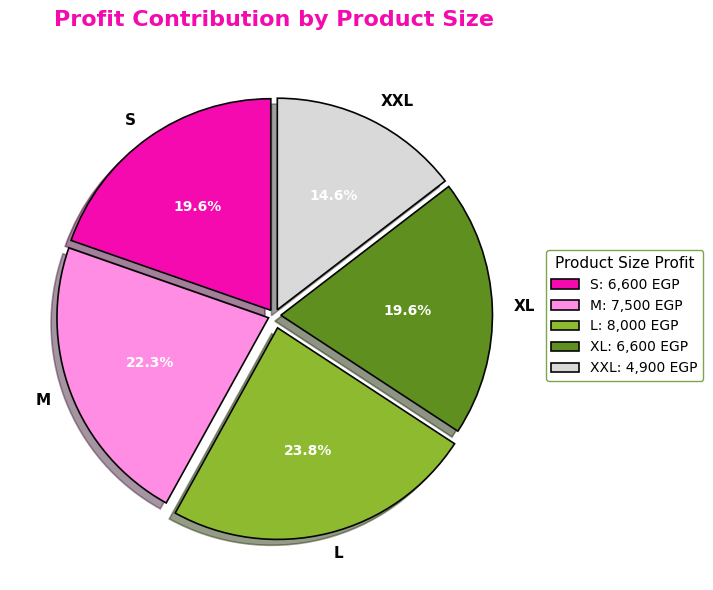

In [43]:
# Data
sizes = ["S", "M", "L", "XL", "XXL"]
profit_per_product = [6600, 7500, 8000, 6600, 4900]

# Easy Organizer Theme Colors
EASY_PINK = "#F40AAE"
EASY_LIGHT_PINK = "#FF8DE3"
EASY_GREEN = "#8DBA2F"
EASY_DARK_GREEN = "#5F8F1F"
EASY_BLACK = "#050505"
EASY_WHITE = "#FFFFFF"
EASY_GRAY = "#D9D9D9"

# Pie chart colors based on the logo
pie_colors = [
    EASY_PINK,
    EASY_LIGHT_PINK,
    EASY_GREEN,
    EASY_DARK_GREEN,
    EASY_GRAY
]

# Create figure
plt.figure(figsize=(8.5, 6), facecolor=EASY_WHITE)

# Create pie chart
wedges, texts, autotexts = plt.pie(
    profit_per_product,
    labels=sizes,
    autopct="%1.1f%%",
    startangle=90,
    colors=pie_colors,
    explode=[0.03, 0.03, 0.06, 0.03, 0.03],
    shadow=True,
    wedgeprops={
        "edgecolor": EASY_BLACK,
        "linewidth": 1.2
    },
    textprops={
        "fontsize": 11,
        "fontweight": "bold",
        "color": EASY_BLACK
    }
)

# Style percentage text
for autotext in autotexts:
    autotext.set_color(EASY_WHITE)
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")

# Title
plt.title(
    "Profit Contribution by Product Size",
    fontsize=16,
    fontweight="bold",
    color=EASY_PINK,
    pad=18
)

# Add legend with actual profit values
legend_labels = [
    f"{size}: {profit:,} EGP"
    for size, profit in zip(sizes, profit_per_product)
]

plt.legend(
    wedges,
    legend_labels,
    title="Product Size Profit",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    facecolor=EASY_WHITE,
    edgecolor=EASY_DARK_GREEN,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()